## Project README

### Supply Chain Data Analysis: Supplier and Warehouse Performance

This project performs a comprehensive analysis of supply chain data to evaluate the performance of suppliers and warehouses. It focuses on calculating and visualizing key performance indicators (KPIs) to provide actionable insights for supply chain decision-makers.

### Goal of the Analysis

The primary goal is to measure supplier and warehouse performance using a set of commonly accepted supply chain KPIs, including:

*   **OTIF % (Perfect Order Rate):** Percentage of orders delivered on time *and* in full quantity without shortage.
*   **On-Time Delivery %:** Percentage of orders delivered on time (or earlier), regardless of quantity completeness.
*   **Defective Rate %:** Percentage of damaged/defective units out of total units received.
*   **Lead Time Variance:** Average difference between actual and promised lead time days (in days).
*   **Total Cost Analysis:** Total expenditure aggregated by supplier and by warehouse.

### Methodology

The analysis follows a structured approach:

1.  **Load Data:** Read `supply_chain_data_updated.xlsx` into a pandas DataFrame.
2.  **Inspect and Clean:** Check for missing values, convert date columns to datetime format, and review descriptive statistics.
3.  **Calculate KPIs:** Compute the five core KPIs for overall performance and individual supplier/warehouse performance.
4.  **Data Visualization:** Create various charts (bar plots, heatmaps) to visually represent the KPIs and facilitate comparison.
5.  **Extract Key Findings:** Summarize overall performance and identify best/worst performers based on the calculated KPIs.

### Key Findings and Insights

**Overall Supply Chain Performance:**

*   **Total Orders:** 100
*   **OTIF %:** 0.00% (Indicates a significant issue with either on-time delivery or in-full quantities, or both).
*   **On-Time Delivery %:** 67.00% (Suggests that while deliveries are often on time, the 'In-Full' condition might be the primary driver of the low OTIF %).
*   **In-Full %:** 0.00% (This is a critical finding, indicating that *no orders* were received in full quantity. This needs immediate investigation).
*   **Defective Rate %:** 2.95%
*   **Average Lead Time Variance:** -0.39 days (On average, deliveries are slightly early, but variance exists).

**Supplier Performance Highlights:**

*   **OTIF Performance:** All suppliers currently show 0.0% OTIF, primarily due to the 0.0% 'In-Full' rate across the board.
*   **Best On-Time Delivery:** Summit Logistics Solutions (100.0%).
*   **Worst On-Time Delivery:** Nexus Commercial Holdings (45.0%).
*   **Highest Defective Rate:** Global Supply Chain Corp (3.4%).
*   **Largest Supplier by Expenditure:** Prime Industries Ltd (779,038 USD).

**Expenditure Analysis:**

*   **Highest Expenditure by Warehouse:** Warehouse B - Jeddah (1,493,308 USD).
*   The heatmap shows a detailed breakdown of expenditure by each supplier to each warehouse, highlighting significant spending with Apex Group at Warehouse B - Jeddah and Summit Logistics Solutions at Warehouse A - Riyadh.

### Concluding Remarks

*   The **0.0% 'In-Full' rate** is the most critical finding and requires urgent attention. This indicates a systemic problem where ordered quantities are never fully received, impacting customer satisfaction and operational efficiency.
*   **OTIF %** remains the most comprehensive indicator. The current 0% highlights the need to address the 'In-Full' component.
*   A high **Defective Rate %** for specific suppliers (e.g., Global Supply Chain Corp) warrants a review of their Quality Agreements.
*   Positive **Lead Time Variance** indicates potential delays, while consistently negative variance might suggest overly conservative promised lead times.
*   **Total Cost Analysis** helps identify major spending areas, allowing for strategic renegotiation or consolidation to achieve economies of scale.

# Supply Chain Data Analysis

**Goal of this analysis:** Measure supplier and warehouse performance by calculating a set of key performance indicators (KPIs) most commonly used in supply chain management:

|   | Indicator (KPI) | Definition |
|---|---|---|
| 1 | **OTIF %** (Perfect Order Rate) | Percentage of orders delivered on time (or earlier) **and in full quantity** without shortage |
| 2 | **On-Time Delivery %** | Percentage of orders delivered on time (or earlier), regardless of quantity completeness |
| 3 | **Defective Rate %** | Percentage of damaged/defective units out of total units received |
| 4 | **Lead Time Variance** | Average difference between actual and promised lead time days (in days) |
| 5 | **Total Cost Analysis** | Total expenditure aggregated by supplier and by warehouse |

We will proceed with the following steps in order: Load Data → Inspect and Clean → Calculate KPIs → Data Visualization → Extract Key Findings.

## 1. Import Required Libraries

We use:
- **pandas**: for reading and processing tabular data.
- **numpy**: for some numerical operations.
- **matplotlib**: for plotting illustrative charts.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
# matplotlib.rcParams['axes.unicode_minus'] = False # Not needed for English
plt.rcParams['figure.figsize'] = (10, 5)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

## 2. Load Data

We read the `supply_chain_data_updated.xlsx` file and display the first few rows to confirm successful loading.

In [ ]:
df = pd.read_excel('supply_chain_data_updated.xlsx', sheet_name='Supply_Data')
print('Number of rows and columns:', df.shape)
df.head()

Number of rows and columns: (100, 13)


,Item_ID,Supplier,Order_Date,Promised_Lead_Time_Days,Promised_Delivery_Date,Actual_Lead_Time_Days,Actual_Delivery_Date,Ordered_Quantity,Received_Quantity,Defective_Units,Unit_Cost_USD,Total_Cost_USD,Warehouse_Location
0,ITEM-5023,Beta Trading,2026-04-17,6,2026-04-23,3,2026-04-20,401,388,4,202.36,81146.36,Warehouse B - Jeddah
1,ITEM-5005,Alpha Logistics,2026-04-07,5,2026-04-12,4,2026-04-11,97,94,5,26.66,2586.02,Warehouse B - Jeddah
2,ITEM-5008,Omega Supply,2026-01-19,6,2026-01-25,7,2026-01-26,80,74,4,98.33,7866.40,Warehouse A - Riyadh
3,ITEM-5035,Gamma Industries,2026-04-21,6,2026-04-27,5,2026-04-26,393,340,13,37.20,14619.60,Warehouse B - Jeddah
4,ITEM-5027,Alpha Logistics,2026-03-17,5,2026-03-22,4,2026-03-21,197,193,10,225.50,44423.50,Warehouse A - Riyadh


## 3. Data Inspection and Cleaning

Before calculating any indicator, we need to ensure:
- No missing values that would affect calculations.
- Date columns are in the correct `datetime` format.
- A quick statistical summary of numerical columns.

In [ ]:
# Check for missing values
print('Missing values in each column:')
print(df.isnull().sum())

# Ensure date columns are of datetime type
date_cols = ['Order_Date', 'Promised_Delivery_Date', 'Actual_Delivery_Date']
for c in date_cols:
    df[c] = pd.to_datetime(df[c])

df.info()

Missing values in each column:
Item_ID                    0
Supplier                   0
Order_Date                 0
Promised_Lead_Time_Days    0
Promised_Delivery_Date     0
Actual_Lead_Time_Days      0
Actual_Delivery_Date       0
Ordered_Quantity           0
Received_Quantity          0
Defective_Units            0
Unit_Cost_USD              0
Total_Cost_USD             0
Warehouse_Location         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Item_ID                  100 non-null    object        
 1   Supplier                 100 non-null    object        
 2   Order_Date               100 non-null    datetime64[ns]
 3   Promised_Lead_Time_Days  100 non-null    int64         
 4   Promised_Delivery_Date   100 non-null    datetime64[ns]
 5   Actual_Lead_Time_Days    100 non-null    in

In [ ]:
# Quick look at descriptive statistics for numerical columns
df.select_dtypes(include=[np.number]).describe().T

,count,mean,std,min,25%,50%,75%,max
Promised_Lead_Time_Days,100.0,6.6300,1.732955,5.00,6.00,6.000,6.00,10.00
Actual_Lead_Time_Days,100.0,6.2400,2.860811,2.00,4.00,6.000,7.00,14.00
Ordered_Quantity,100.0,277.0500,148.044723,53.00,145.75,279.000,421.25,498.00
Received_Quantity,100.0,250.4100,138.109830,46.00,109.25,229.000,394.75,480.00
Defective_Units,100.0,7.3800,6.591669,0.00,2.75,5.000,11.25,24.00
Unit_Cost_USD,100.0,117.5213,65.549634,14.41,69.53,115.740,168.66,236.71
Total_Cost_USD,100.0,33748.4205,29442.588491,2137.78,10306.00,20327.185,49405.80,117881.58


## 4. Calculate Key Performance Indicators (KPIs)

### 4.1 On-Time Delivery %

We compare `Actual_Delivery_Date` with `Promised_Delivery_Date`:
- If the actual delivery date is **less than or equal to** the promised date → Delivered on time (On-Time).

In [ ]:
df['On_Time'] = df['Actual_Delivery_Date'] <= df['Promised_Delivery_Date']

on_time_pct = df['On_Time'].mean() * 100
print(f'On-Time Delivery %: {on_time_pct:.2f}%')

On-Time Delivery %: 67.00%


### 4.2 On-Time, In-Full (OTIF %) Rate

An order is considered **OTIF (Perfect Order)** if both conditions are met:
1. Delivery was on time (`On_Time = True`).
2. The received quantity (`Received_Quantity`) **equals** the ordered quantity (`Ordered_Quantity`) in full (In-Full).

In [ ]:
df['In_Full'] = df['Received_Quantity'] >= df['Ordered_Quantity']
df['OTIF'] = df['On_Time'] & df['In_Full']

otif_pct = df['OTIF'].mean() * 100
in_full_pct = df['In_Full'].mean() * 100

print(f'In-Full %: {in_full_pct:.2f}%')
print(f'On-Time, In-Full (OTIF %) Rate: {otif_pct:.2f}%')

In-Full %: 0.00%
On-Time, In-Full (OTIF %) Rate: 0.00%


### 4.3 Defective Rate %

The ratio of defective units (`Defective_Units`) to total received units (`Received_Quantity`) for all records.

In [ ]:
total_defective = df['Defective_Units'].sum()
total_received = df['Received_Quantity'].sum()
defective_rate = (total_defective / total_received) * 100

print(f'Total Defective Units: {total_defective:,}')
print(f'Total Received Units: {total_received:,}')
print(f'Defective Rate %: {defective_rate:.2f}%')

# Also calculate the rate at the order level for later aggregation by supplier
df['Defective_Rate_Order'] = (df['Defective_Units'] / df['Received_Quantity']) * 100

Total Defective Units: 738
Total Received Units: 25,041
Defective Rate %: 2.95%


### 4.4 Average Lead Time Variance

Variance = Actual Lead Time Days (`Actual_Lead_Time_Days`) − Promised Lead Time Days (`Promised_Lead_Time_Days`).

- **Positive value** → Delayed beyond the promised date.
- **Negative value** → Arrived before the promised date.

In [ ]:
df['Lead_Time_Variance'] = df['Actual_Lead_Time_Days'] - df['Promised_Lead_Time_Days']

avg_variance = df['Lead_Time_Variance'].mean()
print(f'Average Lead Time Variance: {avg_variance:.2f} days')
print(f'  (Positive value means a delay, negative means early arrival)')

df['Lead_Time_Variance'].describe()

Average Lead Time Variance: -0.39 days
  (Positive value means a delay, negative means early arrival)


,Lead_Time_Variance
count,100.000000
mean,-0.390000
std,1.716792
min,-3.000000
25%,-2.000000
50%,-1.000000
75%,1.000000
max,4.000000


### 4.5 Total Cost Analysis by Supplier and Warehouse

In [ ]:
cost_by_supplier = df.groupby('Supplier')['Total_Cost_USD'].sum().sort_values(ascending=False)
print('Total Expenditure by Supplier (USD):')
print(cost_by_supplier)

Total Expenditure by Supplier (USD):
Supplier
Gamma Industries    779037.88
Beta Trading        758170.26
Alpha Logistics     689034.03
Omega Supply        643987.93
Delta Corp          504611.95
Name: Total_Cost_USD, dtype: float64


In [ ]:
cost_by_warehouse = df.groupby('Warehouse_Location')['Total_Cost_USD'].sum().sort_values(ascending=False)
print('Total Expenditure by Warehouse (USD):')
print(cost_by_warehouse)

Total Expenditure by Warehouse (USD):
Warehouse_Location
Warehouse B - Jeddah    1493307.62
Warehouse A - Riyadh     976070.01
Warehouse C - Dammam     905464.42
Name: Total_Cost_USD, dtype: float64


### Change Supplier Names

First, let's see the current unique supplier names.

In [ ]:
print("Current unique supplier names:")
print(df['Supplier'].unique())

Current unique supplier names:
['Beta Trading' 'Alpha Logistics' 'Omega Supply' 'Gamma Industries'
 'Delta Corp']


Now, I will replace the old supplier names with new ones. Note: If you have specific names in mind, you can modify the `supplier_name_mapping` dictionary below.

In [ ]:
# Define the mapping for old to new supplier names
# You can modify these names as needed
supplier_name_mapping = {
    'Beta Trading': 'Apex Group',
    'Alpha Logistics': 'Summit Logistics Solutions',
    'Omega Supply': 'Global Supply Chain Corp',
    'Gamma Industries': 'Prime Industries Ltd',
    'Delta Corp': 'Nexus Commercial Holdings'
}

df['Supplier'] = df['Supplier'].replace(supplier_name_mapping)

print("Updated unique supplier names:")
print(df['Supplier'].unique())

Updated unique supplier names:
['Apex Group' 'Summit Logistics Solutions' 'Global Supply Chain Corp'
 'Prime Industries Ltd' 'Nexus Commercial Holdings']


### 4.6 Comprehensive Summary Table of KPIs Grouped by Supplier

We aggregate all the previous indicators (OTIF, On-Time, Defective Rate, Lead Time Variance, Total Cost) into a single table for each supplier to facilitate comparison.

In [ ]:
supplier_summary = df.groupby('Supplier').apply(
    lambda g: pd.Series({
        'Orders_Count': len(g),
        'OTIF_%': g['OTIF'].mean() * 100,
        'On_Time_%': g['On_Time'].mean() * 100,
        'In_Full_%': g['In_Full'].mean() * 100,
        'Defective_Rate_%': (g['Defective_Units'].sum() / g['Received_Quantity'].sum()) * 100,
        'Avg_Lead_Time_Variance_days': g['Lead_Time_Variance'].mean(),
        'Total_Cost_USD': g['Total_Cost_USD'].sum()
    })
).sort_values('OTIF_%', ascending=False)

supplier_summary.round(2)


/tmp/ipykernel_7899/1563429601.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  supplier_summary = df.groupby('Supplier').apply(


,Orders_Count,OTIF_%,On_Time_%,In_Full_%,Defective_Rate_%,Avg_Lead_Time_Variance_days,Total_Cost_USD
Supplier,,,,,,,
Apex Group,18.0,0.0,66.67,0.0,2.61,-0.50,758170.26
Global Supply Chain Corp,20.0,0.0,55.00,0.0,3.43,-0.20,643987.93
Nexus Commercial Holdings,20.0,0.0,45.00,0.0,2.99,0.75,504611.95
Prime Industries Ltd,25.0,0.0,72.00,0.0,2.52,-0.60,779037.88
Summit Logistics Solutions,17.0,0.0,100.00,0.0,3.27,-1.53,689034.03


## 5. Visualizations

We visually present the key indicators to facilitate reading the results and comparing supplier performance.

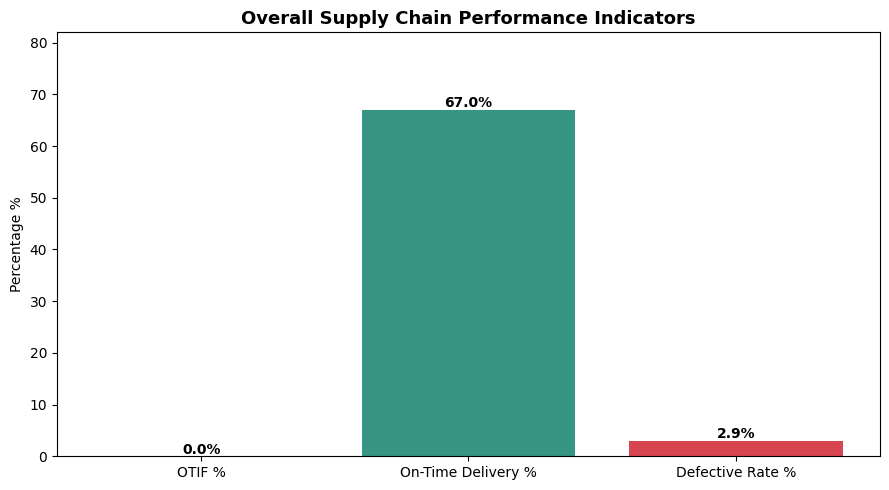

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
labels = ['OTIF %', 'On-Time Delivery %', 'Defective Rate %']
values = [otif_pct, on_time_pct, defective_rate]
colors = ['#2E86AB', '#379683', '#D64550']

bars = ax.bar(labels, values, color=colors)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

ax.set_ylabel('Percentage %')
ax.set_title('Overall Supply Chain Performance Indicators', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values) + 15)
plt.tight_layout()
plt.show()

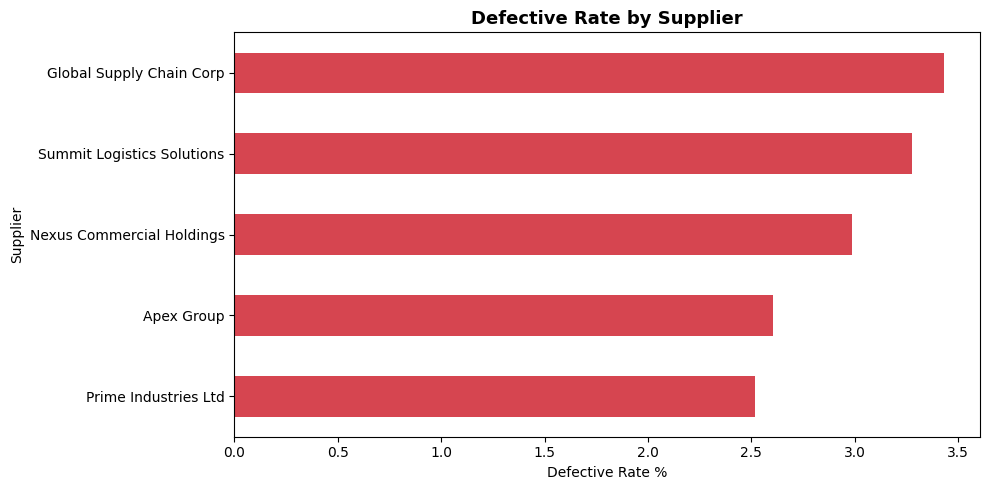

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
supplier_summary['Defective_Rate_%'].sort_values().plot(kind='barh', color='#D64550', ax=ax)
ax.set_xlabel('Defective Rate %')
ax.set_title('Defective Rate by Supplier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

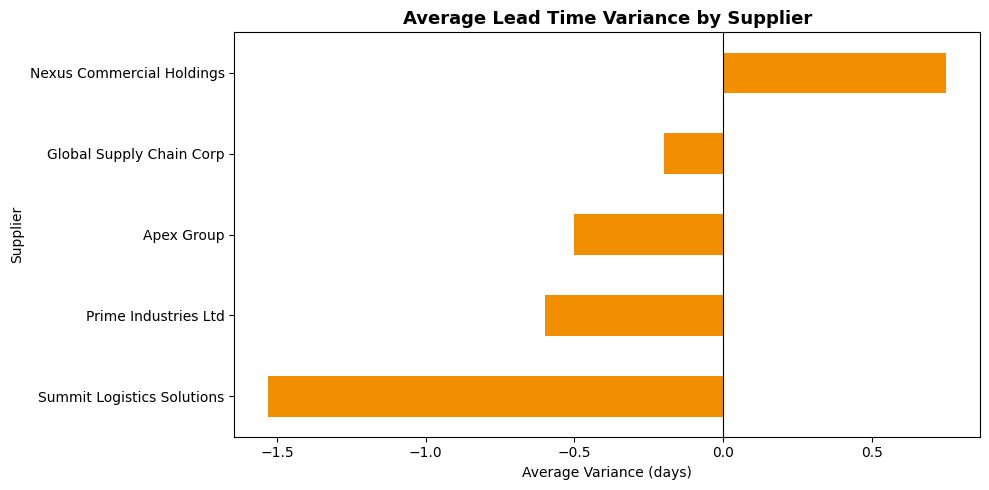

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
supplier_summary['Avg_Lead_Time_Variance_days'].sort_values().plot(kind='barh', color='#F18F01', ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Average Variance (days)')
ax.set_title('Average Lead Time Variance by Supplier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

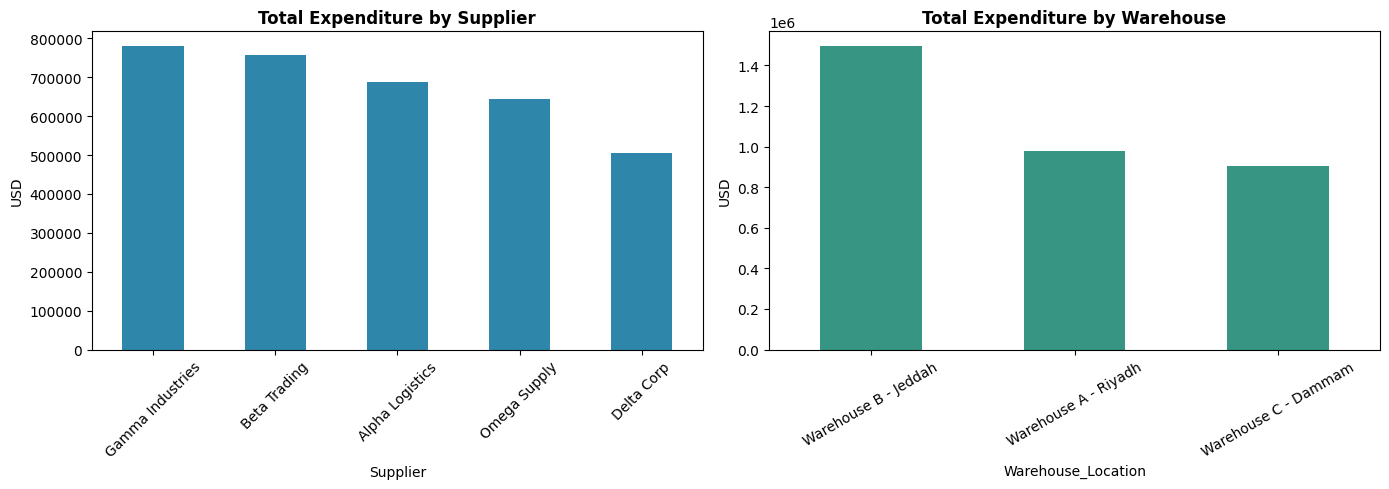

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

cost_by_supplier.plot(kind='bar', color='#2E86AB', ax=axes[0])
axes[0].set_title('Total Expenditure by Supplier', fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].tick_params(axis='x', rotation=45)

cost_by_warehouse.plot(kind='bar', color='#379683', ax=axes[1])
axes[1].set_title('Total Expenditure by Warehouse', fontweight='bold')
axes[1].set_ylabel('USD')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

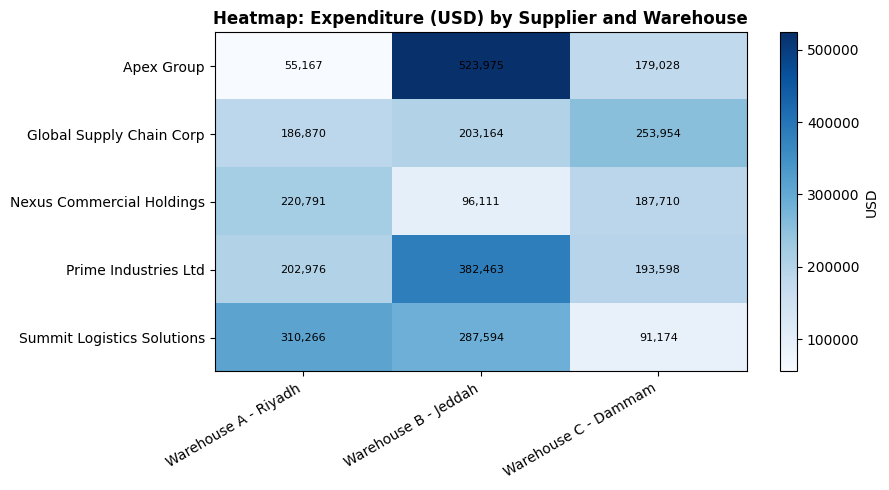

Warehouse_Location,Warehouse A - Riyadh,Warehouse B - Jeddah,Warehouse C - Dammam
Supplier,,,
Apex Group,55167.01,523975.45,179027.80
Global Supply Chain Corp,186869.61,203164.02,253954.30
Nexus Commercial Holdings,220791.03,96110.70,187710.22
Prime Industries Ltd,202976.34,382463.27,193598.27
Summit Logistics Solutions,310266.02,287594.18,91173.83


In [ ]:
# Heatmap: Expenditure by Supplier x Warehouse
pivot_cost = df.pivot_table(index='Supplier', columns='Warehouse_Location',
                             values='Total_Cost_USD', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(9,5))
im = ax.imshow(pivot_cost.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(pivot_cost.columns)))
ax.set_xticklabels(pivot_cost.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot_cost.index)))
ax.set_yticklabels(pivot_cost.index)

for i in range(len(pivot_cost.index)):
    for j in range(len(pivot_cost.columns)):
        ax.text(j, i, f'{pivot_cost.values[i,j]:,.0f}', ha='center', va='center', fontsize=8)

ax.set_title('Heatmap: Expenditure (USD) by Supplier and Warehouse', fontweight='bold')
fig.colorbar(im, ax=ax, label='USD')
plt.tight_layout()
plt.show()

pivot_cost

## 6. Conclusion and Key Findings

A final numerical summary of all indicators will be presented, which can be used as a quick report (Executive Summary) for supply chain decision-makers.

In [ ]:

print(' Supply Chain Key Performance Indicators Summary ')
print('_'*55)
print(f'Total Orders              : {len(df)}')
print(f'OTIF %                    : {otif_pct:.2f}%')
print(f'On-Time Delivery %        : {on_time_pct:.2f}%')
print(f'In-Full %                 : {in_full_pct:.2f}%')
print(f'Defective Rate %          : {defective_rate:.2f}%')
print(f'Avg Lead Time Variance    : {avg_variance:.2f} days')
print(f'_'*55)
print('Best Supplier by OTIF   :', supplier_summary['OTIF_%'].idxmax(),
      f'({supplier_summary["OTIF_%"].max():.1f}%)')
print('Worst Supplier by OTIF  :', supplier_summary['OTIF_%'].idxmin(),
      f'({supplier_summary["OTIF_%"].min():.1f}%)')
print('Supplier with Highest Defective Rate:', supplier_summary['Defective_Rate_%'].idxmax(),
      f'({supplier_summary["Defective_Rate_%"].max():.1f}%)')
print('Largest Supplier by Expenditure:', cost_by_supplier.idxmax(),
      f'({cost_by_supplier.max():,.0f} USD)')
print('_'*55)

 Supply Chain Key Performance Indicators Summary 
_______________________________________________________
Total Orders              : 100
OTIF %                    : 0.00%
On-Time Delivery %        : 67.00%
In-Full %                 : 0.00%
Defective Rate %          : 2.95%
Avg Lead Time Variance    : -0.39 days
_______________________________________________________
Best Supplier by OTIF   : Apex Group (0.0%)
Worst Supplier by OTIF  : Apex Group (0.0%)
Supplier with Highest Defective Rate: Global Supply Chain Corp (3.4%)
Largest Supplier by Expenditure: Gamma Industries (779,038 USD)
_______________________________________________________


### Concluding Remarks

- **OTIF %** is the most comprehensive indicator as it combines on-time delivery and in-full quantity, making it the most relied upon for strategic supplier performance evaluation.
- A high **Defective Rate %** for a specific supplier may warrant a review of the Quality Agreement with them.
- Repeatedly positive **Lead Time Variance** indicates a structural problem in the supplier's time planning, while repeatedly negative values might mean that time promises are inaccurate (overly conservative).
- The **Total Cost Analysis** table can be used to identify suppliers/warehouses with the highest expenditures to renegotiate prices or consolidate orders to achieve Economies of Scale.